In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


# 📈 Linear Regression — Mathematical Intuition

## 1. What is Linear Regression?

Linear Regression is a **supervised learning algorithm** used to predict a **continuous numerical value**.

It finds the **best-fitting straight line** between `X` and `Y`.

### Equation

$$
\hat{y} = mx + b
$$

* **X** → Independent variable
* **Y** → Actual output
* **ŷ** → Predicted output
* **m** → Slope
* **b** → Intercept

---

## 2. Dataset

**Dataset:** Student Study Hours

* **X:** Hours studied
* **Y:** Exam score

### Goal

> Predict the exam score based on the number of hours studied.

---

## 3. Mathematical Intuition

### Mean of X

$$
\bar{x} = \frac{\sum x}{n}
$$

### Mean of Y

$$
\bar{y} = \frac{\sum y}{n}
$$

### Slope (m)

$$
m =
\frac{\sum (x-\bar{x})(y-\bar{y})}
{\sum (x-\bar{x})^2}
$$

### Intercept (b)

$$
b = \bar{y} - m\bar{x}
$$

### Final Regression Equation

$$
\boxed{\hat{y} = mx + b}
$$

---

## 4. Prediction

Once we calculate `m` and `b`, we can predict `Y` for any new value of `X`.

Example:

$$
m = 10,\quad b = 10
$$

Therefore:

$$
\hat{y} = 10x + 10
$$

For `x = 5`:

$$
\hat{y} = 10(5) + 10 = 60
$$

**Predicted score = 60**

---

## 5. Error / Cost

### Error

$$
Error = y - \hat{y}
$$

### Mean Squared Error (MSE)

$$
MSE = \frac{1}{n}\sum(y-\hat{y})^2
$$

### Main Goal

> Find the values of **m** and **b** that give the **minimum MSE**.

---

## 6. Learning Flow

```text
Dataset
   ↓
Calculate X̄ and Ȳ
   ↓
Calculate Slope (m)
   ↓
Calculate Intercept (b)
   ↓
ŷ = mx + b
   ↓
Make Predictions
   ↓
Calculate Error / MSE
```

### 🧠 Key Intuition

> **Linear Regression finds the best straight line representing the relationship between X and Y, which allows us to use X to predict Y.**


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


In [6]:
df = pd.read_csv('/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv')

df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [7]:
df.shape

(30, 3)

In [8]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [9]:
df.head(10)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [13]:
X =  df["YearsExperience"]
y = df["Salary"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
0    1.2
1    1.4
2    1.6
3    2.1
4    2.3
Name: YearsExperience, dtype: float64

y:
0    39344.0
1    46206.0
2    37732.0
3    43526.0
4    39892.0
Name: Salary, dtype: float64


In [37]:
class LinReg:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self,X,y):
        numerator = 0
        denominator = 0

        numerator += ((X-X.mean())*(y-y.mean()))
        denominator += (X-X.mean())**2

        self.m = numerator/denominator
        self.b = y.mean()-(self.m*X.mean())

    def predict(self,X):
        return self.m*X + self.b
    

In [38]:
model = LinReg()
model.fit(X,y)

print("Slope (m):", model.m)
print("Intercept (b):", model.b)

Slope (m): 0       8700.949367
1       7424.750831
2      10036.363636
3       9802.213280
4      11599.143469
5       8022.513812
6       6852.881844
7      10200.946372
8       5469.085174
9      11661.570248
10      9045.990566
11     15387.563452
12     14502.030457
13     15595.054945
14     18309.836066
15     19512.096774
16     46753.125000
17   -531375.000000
18      9136.363636
19     26121.844660
20     10584.080717
21     12464.552239
22      9780.541237
23     13097.806005
24      9870.472441
25      8023.236890
26      9784.872611
27      8545.567652
28      9302.406417
29      8843.637532
dtype: float64
Intercept (b): 0     2.890286e+04
1     3.581135e+04
2     2.167382e+04
3     2.294135e+04
4     1.321397e+04
5     3.257546e+04
6     3.890707e+04
7     2.078288e+04
8     4.639802e+04
9     1.287603e+04
10    2.703504e+04
11   -7.294010e+03
12   -2.500325e+03
13   -8.417231e+03
14   -2.311325e+04
15   -2.962148e+04
16   -1.770863e+05
17    2.952514e+06
18    2.654582e+0

In [39]:
predictions = model.predict(X)

print(predictions[:5])

0    39344.0
1    46206.0
2    37732.0
3    43526.0
4    39892.0
dtype: float64


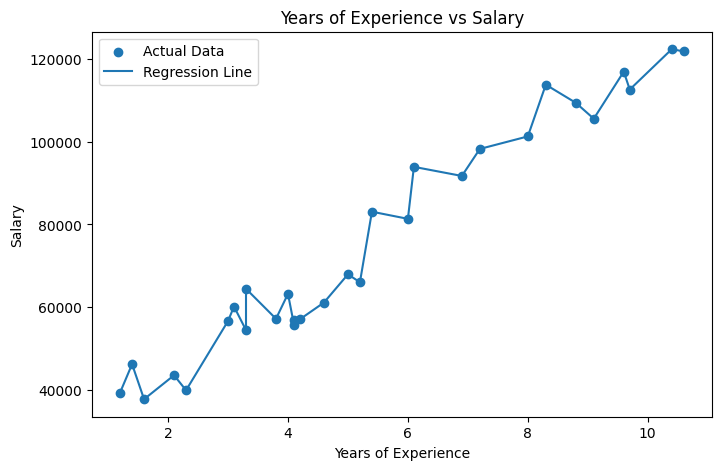

In [40]:
plt.figure(figsize=(8, 5))

# Actual data points
plt.scatter(X, y, label="Actual Data")

# Regression line
plt.plot(X, predictions, label="Regression Line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.legend()
plt.show()